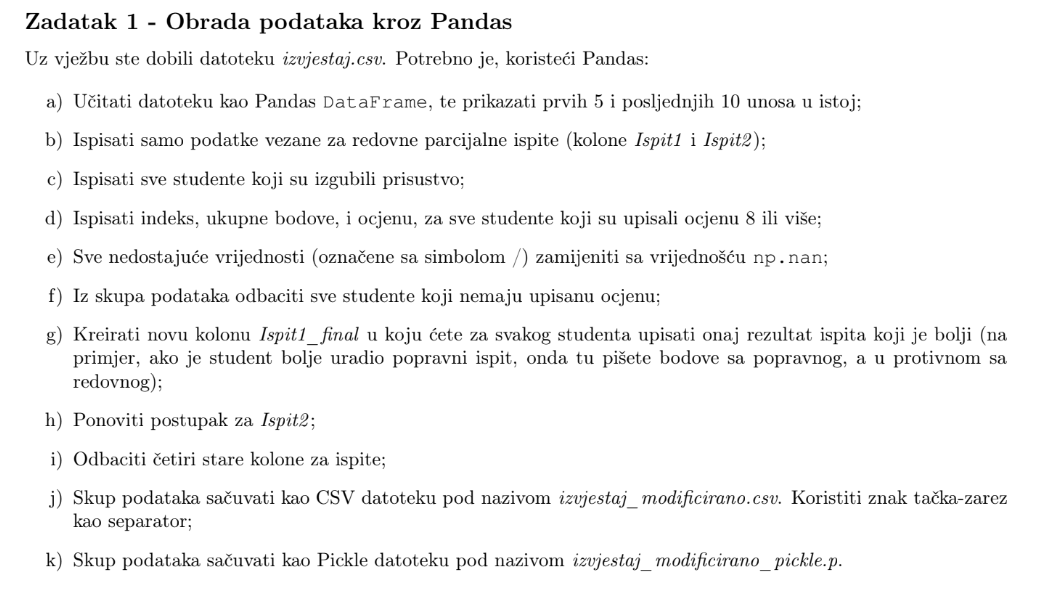

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('izvjestaj.csv', sep=',')

print("prvih 5:")
display(df.head(5))

print("zadnjih 10:")
display(df.tail(10))
for col in df.columns:
    print(repr(col))

df = df.replace('/', np.nan)

numeric_cols = ['Prisustvo', 'Ispit1', 'Ispit2', 'Ispit1_popravni',
                'Ispit2_popravni', 'UKUPNO', 'Ocjena']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
#parcijala
print("kolone ispit1 ispit2:")
display(df[['Ispit1', 'Ispit2']])


print("bez prisustva:")
display(df[df['Prisustvo'] == 0])


print("studenti sa ocjenom 8 i vise:")
rez_d = df[df['Ocjena'] >= 8][['Indeks', 'UKUPNO', 'Ocjena']]
display(rez_d)

print("podaci poslije zamjenje sa NaN:")
display(df)

#bez upisane ocjene
df = df.dropna(subset=['Ocjena'])

print("sa izbacenim studentima bez ocjene:")
display(df)

#ispitfinal nova kolona
df['Ispit1_final'] = df[['Ispit1', 'Ispit1_popravni']].max(axis=1)

print("kolona Ispit1_final:")
display(df[['Ispit1', 'Ispit1_popravni', 'Ispit1_final']])

#isto samo za ispit2
df['Ispit2_final'] = df[['Ispit2', 'Ispit2_popravni']].max(axis=1)

print("kolonaIspit2_final:")
display(df[['Ispit2', 'Ispit2_popravni', 'Ispit2_final']])

#odbacila sam stare ispite
df = df.drop(columns=['Ispit1', 'Ispit1_popravni', 'Ispit2', 'Ispit2_popravni'])

print("konacan rezultat:")
display(df)


df.to_csv('izvjestaj_modificirano.csv', sep=';', index=False)

#sacuvano u pickle
df.to_pickle('izvjestaj_modificirano_pickle.p')

print("uspjesno")

prvih 5:


,id,Indeks,Prisustvo,Ispit1,Ispit2,Ispit1_popravni,Ispit2_popravni,UKUPNO,Ocjena
0,1,94-ST,10,9.4,7.5,12.08,13.73,35.81,7
1,2,77-ST,10,8.5,/,/,/,35.50,7
2,3,69-ST,10,17,/,/,/,39.50,9
3,4,79-ST,0,7.6,4.8,/,/,12.40,/
4,5,89-ST,10,10.6,12.5,12.58,/,35.08,6


zadnjih 10:


,id,Indeks,Prisustvo,Ispit1,Ispit2,Ispit1_popravni,Ispit2_popravni,UKUPNO,Ocjena
37,38,71-ST,10,/,/,/,/,42.16,8
38,39,54-ST,10,/,/,/,/,19.35,/
39,40,60-ST,10,10,/,/,/,38.50,6
40,41,48-ST,10,/,/,/,/,10.00,6
41,42,61-ST,10,/,/,/,/,23.12,/
42,43,1-ST,10,/,/,/,/,10.00,/
43,44,88-ST,10,/,/,/,/,37.00,7
44,45,75-ST,10,/,/,9.83,13.5,33.33,6
45,46,67-ST,10,16.5,/,/,/,39.50,7
46,47,81-ST,10,15.7,17.3,/,/,43.00,8


'id'
'Indeks'
'Prisustvo'
'Ispit1'
'Ispit2'
'Ispit1_popravni'
'Ispit2_popravni'
'UKUPNO'
'Ocjena'
kolone ispit1 ispit2:


...

kolonaIspit2_final:


,Ispit2,Ispit2_popravni,Ispit2_final
0,7.5,13.73,13.73
1,NaN,NaN,NaN
2,NaN,NaN,NaN
4,12.5,NaN,12.50
5,NaN,12.83,12.83
6,12.5,NaN,12.50
7,NaN,NaN,NaN
9,NaN,NaN,NaN
10,NaN,NaN,NaN
11,7.8,16.30,16.30


konacan rezultat:


,id,Indeks,Prisustvo,UKUPNO,Ocjena,Ispit1_final,Ispit2_final
0,1,94-ST,10,35.81,7.0,12.08,13.73
1,2,77-ST,10,35.50,7.0,8.50,NaN
2,3,69-ST,10,39.50,9.0,17.00,NaN
4,5,89-ST,10,35.08,6.0,12.58,12.50
5,6,78-ST,0,25.91,6.0,13.08,12.83
6,7,93-ST,10,35.17,8.0,12.67,12.50
7,8,68-ST,10,50.00,9.0,NaN,NaN
9,10,92-ST,10,42.06,9.0,NaN,NaN
10,11,65-ST,10,43.19,8.0,NaN,NaN
11,12,70-ST,10,39.30,7.0,13.00,16.30


uspjesno


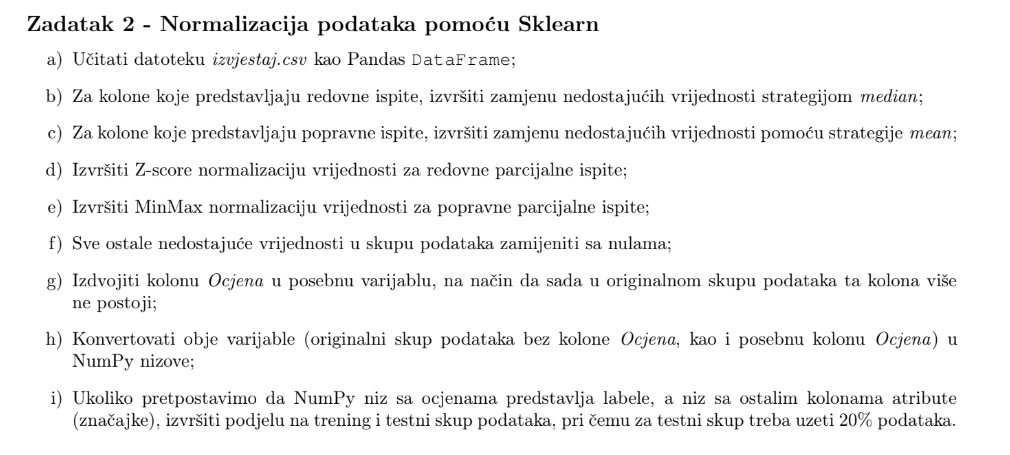

In [5]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split


df = pd.read_csv('izvjestaj.csv', sep=',')

#ciscenje kolone
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)


df = df.replace('/', np.nan)


numeric_cols = ['Prisustvo', 'Ispit1', 'Ispit2', 'Ispit1_popravni',
                'Ispit2_popravni', 'UKUPNO', 'Ocjena']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("podaci:")
display(df)


redovni_ispiti = ['Ispit1', 'Ispit2']
imputer_median = SimpleImputer(strategy='median')
df[redovni_ispiti] = imputer_median.fit_transform(df[redovni_ispiti])

print("nakon median imputa za redovne ispite:")
display(df[redovni_ispiti])

#c
popravni_ispiti = ['Ispit1_popravni', 'Ispit2_popravni']
imputer_mean = SimpleImputer(strategy='mean')
df[popravni_ispiti] = imputer_mean.fit_transform(df[popravni_ispiti])

print("nakon mean imputa za popravne:")
display(df[popravni_ispiti])

#normalizacija za redovne parcijalne ispite
scaler_z = StandardScaler()
df[redovni_ispiti] = scaler_z.fit_transform(df[redovni_ispiti])

print("nakon normalizacije za redovne ispite:")
display(df[redovni_ispiti])

#MinMax normalizacija
scaler_minmax = MinMaxScaler()
df[popravni_ispiti] = scaler_minmax.fit_transform(df[popravni_ispiti])

print("nakon minmax normalizacije:")
display(df[popravni_ispiti])

#sve ostalo zamijenila nulama
df = df.fillna(0)

print("nakon zamjene:")
display(df)

#izdvojila ocjenu i uklonila iz skupa
y = df['Ocjena']
X = df.drop(columns=['Ocjena'])

print("x podaci bez ocjena:")
display(X)

print("ocjene:")
display(y)


X_np = X.to_numpy()
y_np = y.to_numpy()

print("NumPy niz X:")
print(X_np)

print("NumPy niz y:")
print(y_np)


X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42
)

print("trening skup:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("testni skup:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

podaci:


,id,Indeks,Prisustvo,Ispit1,Ispit2,Ispit1_popravni,Ispit2_popravni,UKUPNO,Ocjena
0,1,94-ST,10,9.4,7.5,12.08,13.73,35.81,7.0
1,2,77-ST,10,8.5,NaN,NaN,NaN,35.50,7.0
2,3,69-ST,10,17.0,NaN,NaN,NaN,39.50,9.0
3,4,79-ST,0,7.6,4.8,NaN,NaN,12.40,NaN
4,5,89-ST,10,10.6,12.5,12.58,NaN,35.08,6.0
5,6,78-ST,0,NaN,NaN,13.08,12.83,25.91,6.0
6,7,93-ST,10,NaN,12.5,12.67,NaN,35.17,8.0
7,8,68-ST,10,NaN,NaN,NaN,NaN,50.00,9.0
8,9,83-ST,0,NaN,NaN,NaN,NaN,0.00,NaN
9,10,92-ST,10,NaN,NaN,NaN,NaN,42.06,9.0


nakon median imputa za redovne ispite:


,Ispit1,Ispit2
0,9.4,7.5
1,8.5,8.7
2,17.0,8.7
3,7.6,4.8
4,10.6,12.5
5,12.5,8.7
6,12.5,12.5
7,12.5,8.7
8,12.5,8.7
9,12.5,8.7


nakon mean imputa za popravne:


...

x podaci bez ocjena:


,id,Indeks,Prisustvo,Ispit1,Ispit2,Ispit1_popravni,Ispit2_popravni,UKUPNO
0,1,94-ST,10,-1.561766,-0.555596,0.795918,0.401146,35.81
1,2,77-ST,10,-2.029964,-0.087900,0.679755,0.490232,35.50
2,3,69-ST,10,2.391904,-0.087900,0.679755,0.490232,39.50
3,4,79-ST,0,-2.498161,-1.607912,0.679755,0.490232,12.40
4,5,89-ST,10,-0.937502,1.393136,0.836735,0.490232,35.08
5,6,78-ST,0,0.050915,-0.087900,0.877551,0.315186,25.91
6,7,93-ST,10,0.050915,1.393136,0.844082,0.490232,35.17
7,8,68-ST,10,0.050915,-0.087900,0.679755,0.490232,50.00
8,9,83-ST,0,0.050915,-0.087900,0.679755,0.490232,0.00
9,10,92-ST,10,0.050915,-0.087900,0.679755,0.490232,42.06


ocjene:


,Ocjena
0,7.0
1,7.0
2,9.0
3,0.0
4,6.0
5,6.0
6,8.0
7,9.0
8,0.0
9,9.0


NumPy niz X:
[[1 '94-ST' 10 -1.5617659452228656 -0.5555960491403172 0.7959183673469388
  0.4011461318051578 35.81]
 [2 '77-ST' 10 -2.029963673663172 -0.08790027046100546 0.6797551020408164
  0.4902318312060433 35.5]
 [3 '69-ST' 10 2.3919037616063856 -0.08790027046100546 0.6797551020408164
  0.4902318312060433 39.5]
 [4 '79-ST' 0 -2.498161402103478 -1.6079115511687696 0.6797551020408164
  0.4902318312060433 12.4]
 [5 '89-ST' 10 -0.937502307302458 1.3931363620234831 0.836734693877551
  0.4902318312060433 35.08]
 [6 '78-ST' 0 0.050915119404855075 -0.08790027046100546
  0.8775510204081632 0.31518624641833826 25.91]
 [7 '93-ST' 10 0.050915119404855075 1.3931363620234831 0.8440816326530612
  0.4902318312060433 35.17]
 [8 '68-ST' 10 0.050915119404855075 -0.08790027046100546
  0.6797551020408164 0.4902318312060433 50.0]
 [9 '83-ST' 0 0.050915119404855075 -0.08790027046100546
  0.6797551020408164 0.4902318312060433 0.0]
 [10 '92-ST' 10 0.050915119404855075 -0.08790027046100546
  0.6797551020408

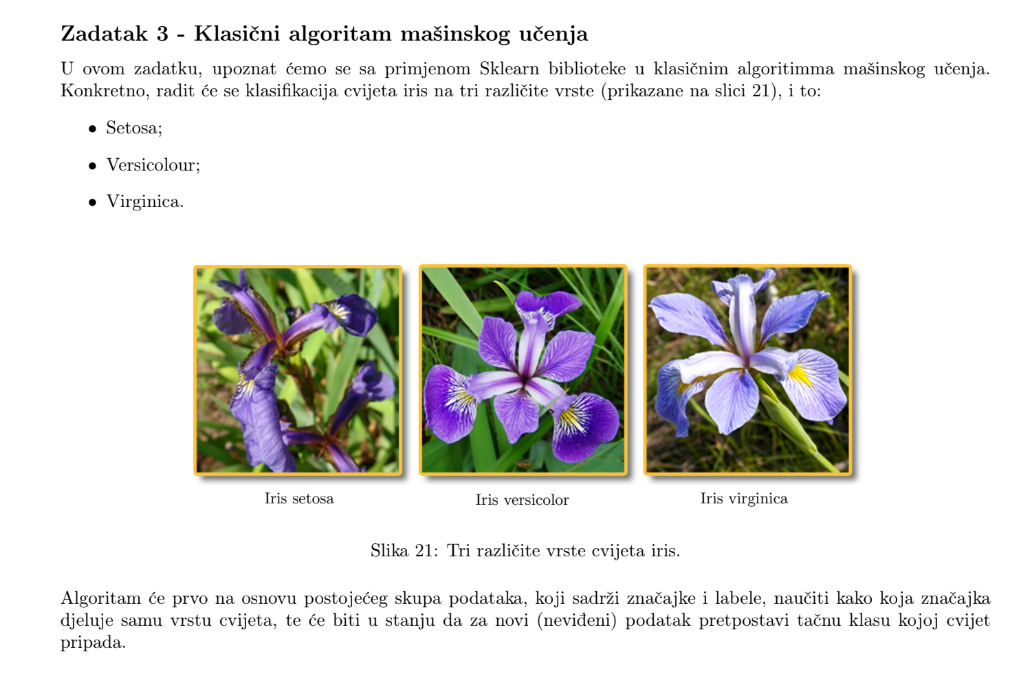

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("nazivi:", feature_names)
print("labele:", target_names)
print("prvih 5 redova X:", X[:5])
print("prvih 5 vrijednosti y:\n", y[:5])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

print("\nOblici skupova:")
print("X_train.shape =", X_train.shape)
print("X_test.shape  =", X_test.shape)
print("y_train.shape =", y_train.shape)
print("y_test.shape  =", y_test.shape)

#klasifikatori
classifier_knn = KNeighborsClassifier(n_neighbors=3)
classifier_knn.fit(X_train, y_train)

#predikcija i tacnost
y_pred = classifier_knn.predict(X_test)

print("predikcija za testni skup:\n", y_pred)
print("stvarne vrijednosti:\n", y_test)
print("tacnost modela:", metrics.accuracy_score(y_test, y_pred))


print("vise razl vrijednosti k, poredjenje:")
for k in [1, 3, 5, 7, 9, 11, 15]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    acc = metrics.accuracy_score(y_test, y_pred_k)
    print(f"k = {k}, tačnost = {acc:.4f}")

nazivi: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
labele: ['setosa' 'versicolor' 'virginica']
prvih 5 redova X: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
prvih 5 vrijednosti y:
 [0 0 0 0 0]

Oblici skupova:
X_train.shape = (105, 4)
X_test.shape  = (45, 4)
y_train.shape = (105,)
y_test.shape  = (45,)
predikcija za testni skup:
 [0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2 1 2 1 2 2 0 1
 0 1 2 2 0 1 2 1]
stvarne vrijednosti:
 [0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2 1 2 1 2 2 0 1
 0 1 2 2 0 2 2 1]
tacnost modela: 0.9777777777777777
vise razl vrijednosti k, poredjenje:
k = 1, tačnost = 0.9778
k = 3, tačnost = 0.9778
k = 5, tačnost = 0.9778
k = 7, tačnost = 0.9778
k = 9, tačnost = 0.9778
k = 11, tačnost = 0.9778
k = 15, tačnost = 0.9778


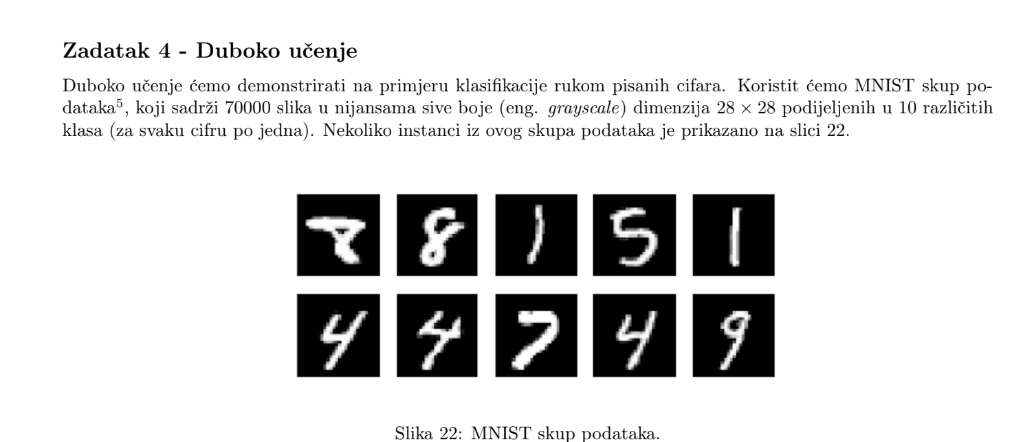

In [6]:
from keras.datasets import mnist
from keras import models, layers
from keras.utils import to_categorical


(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("br slika u trening skupu:", x_train.shape[0])
print("br slika u testnom skupu:", x_test.shape[0])

print("Shape x_train:", x_train.shape)
print("Shape y_train:", y_train.shape)
print("Shape x_test:", x_test.shape)
print("Shape y_test:", y_test.shape)

print("br bajta x_train:", x_train.nbytes)
print("br bajta x_test:", x_test.nbytes)

# slike u vektore i skaliranje na [0, 1]
train_images = x_train.reshape((x_train.shape[0], 28 * 28))
train_images = train_images.astype('float32') / 255

test_images = x_test.reshape((x_test.shape[0], 28 * 28))
test_images = test_images.astype('float32') / 255

print("nakon reshape i normalizacije:")
print("shape train_images:", train_images.shape)
print("shape test_images:", test_images.shape)
print("broj bajta train_images:", train_images.nbytes)
print("broj bajta test_images:", test_images.nbytes)

#kreiran model
network = models.Sequential()
network.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
network.add(layers.Dense(10, activation='softmax'))

print("\nModel kreiran.")

# d) Kompiliranje modela
network.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print("kompajliran")

#one-hot kodiranje labela
train_labels = to_categorical(y_train)
test_labels = to_categorical(y_test)

print("\nShape train_labels:", train_labels.shape)
print("Shape test_labels:", test_labels.shape)

#treniranje mreže
network.fit(train_images, train_labels, epochs=5, batch_size=128)

#evaluacija na testnom skupu
test_loss, test_acc = network.evaluate(test_images, test_labels)

print("tacnost za testni skup:", test_acc)
print("gubitak na testnom skupu:", test_loss)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
br slika u trening skupu: 60000
br slika u testnom skupu: 10000
Shape x_train: (60000, 28, 28)
Shape y_train: (60000,)
Shape x_test: (10000, 28, 28)
Shape y_test: (10000,)
br bajta x_train: 47040000
br bajta x_test: 7840000
nakon reshape i normalizacije:
shape train_images: (60000, 784)
shape test_images: (10000, 784)
broj bajta train_images: 188160000
broj bajta test_images: 31360000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model kreiran.
kompajliran

Shape train_labels: (60000, 10)
Shape test_labels: (10000, 10)
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9239 - loss: 0.2651
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9676 - loss: 0.1092
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9782 - loss: 0.0722
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9849 - loss: 0.0521
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9891 - loss: 0.0392
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9801 - loss: 0.0666
tacnost za testni skup: 0.9800999760627747
gubitak na testnom skupu: 0.06662239134311676
